In [2]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

import tensorflow as tf
from tensorflow.keras import layers

In [3]:
df = pd.read_csv('Final_Augmented_dataset_Diseases_and_Symptoms.csv')
display(df.head())


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df['diseases'].unique()

<ArrowStringArray>
[                  'panic disorder',                 'vocal cord polyp',
                  'turner syndrome',                   'cryptorchidism',
 'poisoning due to ethylene glycol',               'atrophic vaginitis',
             'fracture of the hand',   'cellulitis or abscess of mouth',
           'eye alignment disorder',   'headache after lumbar puncture',
 ...
                'asperger syndrome',                        'mucositis',
                       'paronychia',            'open wound of the jaw',
         'white blood cell disease',                   'kaposi sarcoma',
                'spondylolisthesis',              'pseudotumor cerebri',
      'conjunctivitis due to virus',           'open wound of the nose']
Length: 773, dtype: str

In [5]:
X = df.drop('diseases', axis=1)
y = df['diseases']

# Display the first few rows of the features DataFrame
display(X.head())
print(f"Number of unique symptoms (features): {X.shape[1]}")

,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,1,0,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0


Number of unique symptoms (features): 377


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

xTrain, xTemp, yTrain, yTemp = train_test_split(
    X, y_encoded, test_size=0.4, random_state=42
)
xVal, xTest, yVal, yTest = train_test_split(
    xTemp, yTemp, test_size=0.5, random_state=42
)

In [8]:
print("xTest shape:", xTest.shape)
print("yTest shape:", yTest.shape)

xTest shape: (49389, 377)
yTest shape: (49389,)


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), str(1)
memory usage: 716.3 MB


In [13]:
print('Total Classes: ', len(le.classes_))
print(le.classes_)

Total Classes:  773
['abdominal aortic aneurysm' 'abdominal hernia' 'abscess of nose'
 'abscess of the lung' 'abscess of the pharynx' 'acanthosis nigricans'
 'acariasis' 'achalasia' 'acne' 'actinic keratosis' 'acute bronchiolitis'
 'acute bronchitis' 'acute bronchospasm'
 'acute fatty liver of pregnancy (aflp)' 'acute glaucoma'
 'acute kidney injury' 'acute otitis media' 'acute pancreatitis'
 'acute respiratory distress syndrome (ards)' 'acute sinusitis'
 'acute stress reaction' 'adhesive capsulitis of the shoulder'
 'adjustment reaction' 'adrenal adenoma' 'adrenal cancer' 'alcohol abuse'
 'alcohol intoxication' 'alcohol withdrawal' 'alcoholic liver disease'
 'allergy' 'allergy to animals' 'alopecia' 'alzheimer disease' 'amblyopia'
 'amyloidosis' 'amyotrophic lateral sclerosis (als)' 'anal fissure'
 'anal fistula' 'anemia' 'anemia due to chronic kidney disease'
 'anemia due to malignancy' 'anemia of chronic disease' 'angina'
 'ankylosing spondylitis' 'anxiety' 'aortic valve disease' 'a

# Neural Net

In [ ]:
nnModel = tf.keras.Sequential([
    layers.Dense(19, activation='relu'), 
    layers.Dense(32, activation='relu'), 
    layers.Dense(16, activation='relu'), 
    layers.Dense(len(le.classes_), activation='softmax')  # Multi-class output
])

nnModel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy'],
)

In [10]:
nnModel.evaluate(xTest, yTest)

1544/1544 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0013 - loss: 6.6505


[6.650548934936523, 0.0012958351289853454]

In [12]:
history = nnModel.fit(
    xTrain, yTrain, 
    epochs=40, 
    batch_size=16, 
    validation_data=(xVal, yVal)
)

Epoch 1/40
9261/9261 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.6814 - loss: 1.1130 - val_accuracy: 0.7306 - val_loss: 0.9381
Epoch 2/40
9261/9261 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.7470 - loss: 0.8278 - val_accuracy: 0.7646 - val_loss: 0.7881
Epoch 3/40
9261/9261 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.7731 - loss: 0.7223 - val_accuracy: 0.7812 - val_loss: 0.7168
Epoch 4/40
9261/9261 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.7874 - loss: 0.6587 - val_accuracy: 0.7852 - val_loss: 0.6847
Epoch 5/40
9261/9261 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.7976 - loss: 0.6184 - val_accuracy: 0.7992 - val_loss: 0.6249
Epoch 6/40
9261/9261 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - accuracy: 0.8047 - loss: 0.5886 - val_accuracy: 0.8069 - val_loss: 0.5918
Epoch 7/40
9261/9261 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.8095 - loss: 0.5664 - val_accuracy: 0.8049 - val_loss: 0.5981
Epoch 8/40
9261/9261 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.8139 - loss: 0

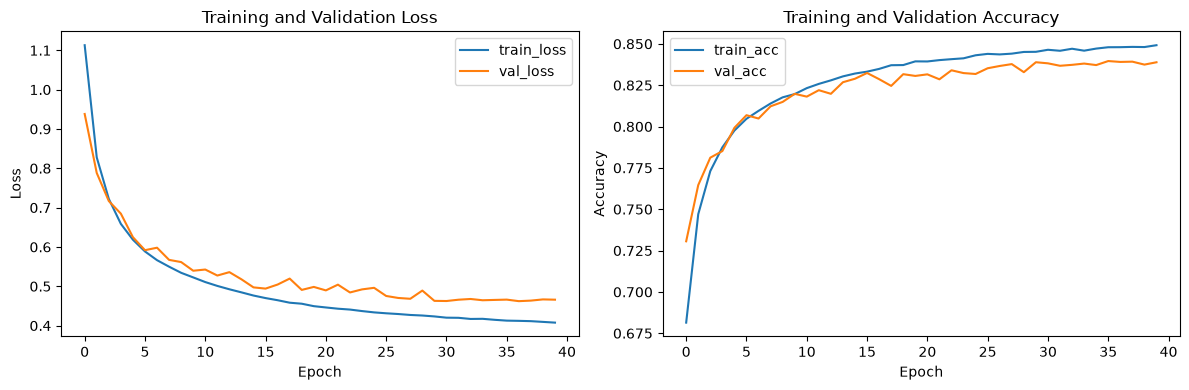

Final training loss: 0.4077
Final validation loss: 0.4660
Final training accuracy: 0.8492
Final validation accuracy: 0.8389


In [13]:
# Plot training history (loss and accuracy)
import pandas as pd
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist_df['loss'], label='train_loss')
plt.plot(hist_df['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_df['accuracy'], label='train_acc')
plt.plot(hist_df['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Final training loss: {hist_df['loss'].iloc[-1]:.4f}")
print(f"Final validation loss: {hist_df['val_loss'].iloc[-1]:.4f}")
print(f"Final training accuracy: {hist_df['accuracy'].iloc[-1]:.4f}")
print(f"Final validation accuracy: {hist_df['val_accuracy'].iloc[-1]:.4f}")

In [14]:
nnModel.evaluate(xTest, yTest)

1544/1544 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8399 - loss: 0.4654


[0.4653889238834381, 0.8399441242218018]

In [26]:
sampleData = df.sample()
xSample = sampleData.drop(columns=['diseases'])
predictSample = nnModel.predict(xSample)

predicted_index = np.argmax(predictSample, axis=1)[0]
predicted_disease = le.inverse_transform([predicted_index])[0]

print('Data')
display(sampleData)
print('Actual disease:', sampleData['diseases'].values[0])
print('Predicted disease:', predicted_disease)
print('Symptoms:', xSample.columns[xSample.iloc[0] == 1].tolist())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Data


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
80483,bell palsy,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


Actual disease: bell palsy
Predicted disease: bell palsy
Symptoms: ['abnormal involuntary movements', 'headache', 'facial pain', 'diminished vision', 'symptoms of eye', 'loss of sensation']


In [ ]:
nnModel.save('disease_symptom_checker_NN_model.keras')